In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np

DATASET_DIR = "/content/drive/MyDrive/Mammogram_Project"

OUTPUT_DIR = "/content/drive/MyDrive/Mammogram_Calc_Shape_Preprocess"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset Directory :", DATASET_DIR)
print("Output Directory  :", OUTPUT_DIR)

print("\nFiles in dataset folder:")
print(os.listdir(DATASET_DIR))


In [4]:
import glob

csv_files = glob.glob(
    os.path.join(DATASET_DIR, "*.csv")
)

print(f"Found {len(csv_files)} CSV files:\n")

for file in csv_files:
    print(os.path.basename(file))

Found 6 CSV files:

mass_case_description_train_set.csv
calc_case_description_train_set.csv
meta.csv
mass_case_description_test_set.csv
dicom_info.csv
calc_case_description_test_set.csv


In [5]:
import pandas as pd

dfs = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        dfs.append(df)
    except:
        pass

data = pd.concat(dfs, ignore_index=True)
data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,...,SOPClassUID,SOPInstanceUID,SamplesPerPixel,SecondaryCaptureDeviceManufacturer,SecondaryCaptureDeviceManufacturerModelName,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyTime
0,P_00001,3.0,LEFT,CC,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1.0,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4.0,MALIGNANT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1.0,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1.0,mass,OVAL,CIRCUMSCRIBED,4.0,BENIGN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Pathology")
display(data["pathology"].value_counts())

print("\nAbnormality Type")
display(data["abnormality type"].value_counts())

print("\nMass Shape")
display(data["mass shape"].value_counts())

print("\nCalc Type")
display(data["calc type"].value_counts())


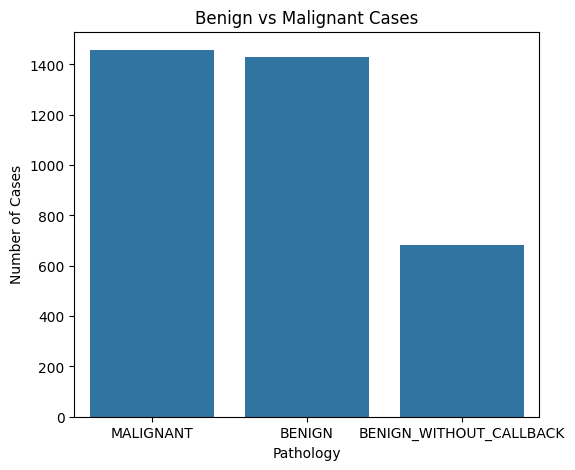

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.countplot(x='pathology', data=data)

plt.title('Benign vs Malignant Cases')
plt.xlabel('Pathology')
plt.ylabel('Number of Cases')
plt.show()

In [8]:

data['image view'].value_counts()

,count
image view,
MLO,1896
CC,1672


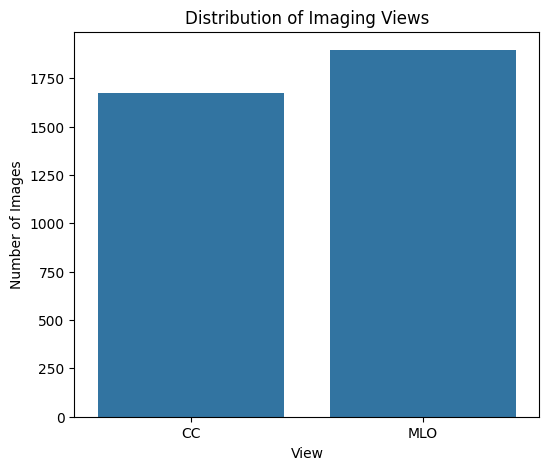

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='image view',
    data=data
)

plt.title('Distribution of Imaging Views')
plt.xlabel('View')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
VALID_SHAPES = [
    "AMORPHOUS",
    "PUNCTATE",
    "LUCENT_CENTER"
]

data = data[
    (data["abnormality type"] == "calcification") &
    (data["calc type"].isin(VALID_SHAPES))
].reset_index(drop=True)

print("Total Calcification Cases:", len(data))

print("\nCalc Type Distribution")
display(data["calc type"].value_counts())


In [ ]:
print("Filtered Dataset Summary")

print("Patients :", data["patient_id"].nunique())
print("Images   :", len(data))

print("\nCalc Types")

display(data["calc type"].value_counts())

print("\nPathology")

display(data["pathology"].value_counts())


In [ ]:
plt.figure(figsize=(12,6))

data['calc type'].value_counts().plot(
    kind='bar'
)

plt.title('Calcification Type Distribution')
plt.xlabel('Calc Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


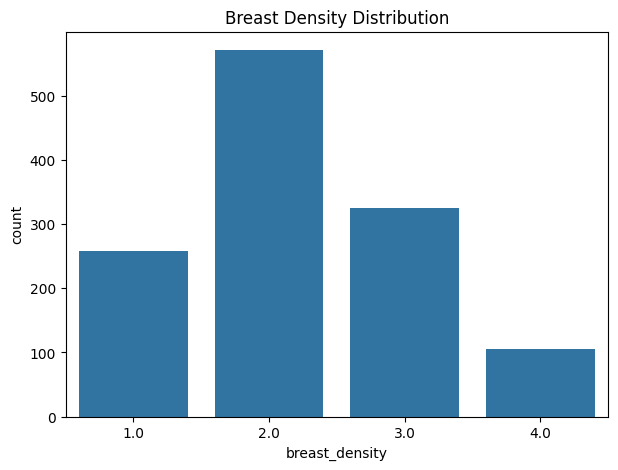

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='breast_density',
    data=data
)

plt.title('Breast Density Distribution')
plt.show()

In [14]:
dicom_csv = os.path.join(DATASET_DIR, "dicom_info.csv")
df = pd.read_csv(dicom_csv)
print(df.shape)
df.head()

(10237, 38)


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [15]:
df['SeriesDescription'].value_counts()

,count
SeriesDescription,
cropped images,3567
ROI mask images,3247
full mammogram images,2857


In [16]:
mammo_df = df[df["SeriesDescription"] == "full mammogram images"].copy()
mask_df = df[df["SeriesDescription"] == "ROI mask images"].copy()
crop_df = df[df["SeriesDescription"] == "cropped images"].copy()

print("Full Mammograms :", len(mammo_df))
print("ROI Masks       :", len(mask_df))
print("Cropped Images  :", len(crop_df))

Full Mammograms : 2857
ROI Masks       : 3247
Cropped Images  : 3567


In [17]:
df = df.dropna(subset=['SeriesDescription']).copy()

In [18]:
mammo_df = df[
    df["SeriesDescription"] == "full mammogram images"
].copy()

mask_df = df[
    df["SeriesDescription"] == "ROI mask images"
].copy()

crop_df = df[
    df["SeriesDescription"] == "cropped images"
].copy()

print(f"Full Mammograms : {len(mammo_df)}")
print(f"ROI Masks       : {len(mask_df)}")
print(f"Cropped Images  : {len(crop_df)}")

Full Mammograms : 2857
ROI Masks       : 3247
Cropped Images  : 3567


In [19]:
import os

df["full_path"] = df["image_path"].str.replace(
    "CBIS-DDSM/jpeg",
    os.path.join(DATASET_DIR, "jpeg"),
    regex=False
)

df["exists"] = df["full_path"].apply(os.path.exists)

print(df["exists"].value_counts())

exists
True    9671
Name: count, dtype: int64


In [20]:
mammo_df = df[
    df["SeriesDescription"] == "full mammogram images"
].copy()

mask_df = df[
    df["SeriesDescription"] == "ROI mask images"
].copy()

print("Full mammograms :", len(mammo_df))
print("ROI masks       :", len(mask_df))

Full mammograms : 2857
ROI masks       : 3247


In [21]:
mammo_dict = {}

for _, row in mammo_df.iterrows():
    mammo_dict[row['PatientID']] = row['full_path']

In [ ]:
shape_lookup = {}
patient_lookup = {}

for _, row in data.iterrows():

    roi_folder = row["ROI mask file path"].split("/")[0]
    shape = row["calc type"]

    shape_lookup[roi_folder] = shape
    patient_lookup[roi_folder] = row["patient_id"]


pairs = []
patient_ids = []   # patient id for each entry in `pairs` -- same order/index as pairs

for _, row in mask_df.iterrows():

    mask_id = row["PatientID"]
    mask_path = row["full_path"]

    # Remove _1, _2, ...
    base_id = mask_id.rsplit("_", 1)[0]

    if base_id in mammo_dict:

        shape = shape_lookup.get(mask_id, None)

        if shape is not None:

            pairs.append(
                (
                    mammo_dict[base_id],
                    mask_path,
                    shape
                )
            )
            patient_ids.append(patient_lookup.get(mask_id))

print("Total pairs:", len(pairs))
print("Total patient ids:", len(patient_ids))
print("Unique patients:", len(set(patient_ids)))


In [23]:
for i in range(5):

    img, mask, shape = pairs[i]

    print("Shape :", shape)
    print("Image :", img)
    print("Mask  :", mask)
    print("-"*80)

Shape : LOBULATED
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.330740809913644315209371578112284206839/1-146.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg
--------------------------------------------------------------------------------
Shape : LOBULATED
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.156666634411136072728329168882908966996/1-288.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.231894579813593468217419823840305212127/2-279.jpg
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.256330807412877366440153727190246662818/1-055.jpg
Mask  : /content/drive/MyDrive/Mammogram_Project/jpeg/1.3.6.1.4.1.9590.100.1.2.286212602510327696024825204783459108873/2-107.jpg
----------

In [24]:
for i in range(5):
    img, mask, shape = pairs[i]
    print("Shape :", shape)
    print(
        "Image PatientID:",
        mammo_df[mammo_df["full_path"] == img]["PatientID"].values
    )
    print(
        "Mask PatientID:",
        mask_df[mask_df["full_path"] == mask]["PatientID"].values
    )
    print("-"*80)

Shape : LOBULATED
Image PatientID: ['Mass-Training_P_00242_RIGHT_CC']
Mask PatientID: ['Mass-Training_P_00242_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : LOBULATED
Image PatientID: ['Mass-Test_P_00882_RIGHT_CC']
Mask PatientID: ['Mass-Test_P_00882_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image PatientID: ['Mass-Training_P_00241_RIGHT_CC']
Mask PatientID: ['Mass-Training_P_00241_RIGHT_CC_1']
--------------------------------------------------------------------------------
Shape : OVAL
Image PatientID: ['Mass-Test_P_00381_LEFT_MLO']
Mask PatientID: ['Mass-Test_P_00381_LEFT_MLO_1']
--------------------------------------------------------------------------------
Shape : IRREGULAR
Image PatientID: ['Mass-Training_P_00348_LEFT_MLO']
Mask PatientID: ['Mass-Training_P_00348_LEFT_MLO_1']
--------------------------------------------------------------------------------


In [25]:
meta = pd.read_csv(os.path.join(DATASET_DIR, "meta.csv"))
meta.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


In [26]:
meta['SeriesDescription'].value_counts()

,count
SeriesDescription,
ROI mask images,3565
full mammogram images,3103
cropped images,107


In [27]:
full_meta = meta[
    meta['SeriesDescription'] == 'full mammogram images'
].copy()

mask_meta = meta[
    meta['SeriesDescription'] == 'ROI mask images'
].copy()

crop_meta = meta[
    meta['SeriesDescription'] == 'cropped images'
].copy()

print(len(full_meta))
print(len(mask_meta))
print(len(crop_meta))

3103
3565
107


In [28]:
common = set(full_meta['StudyInstanceUID']) & \
         set(mask_meta['StudyInstanceUID'])

print("Common studies:", len(common))

Common studies: 0


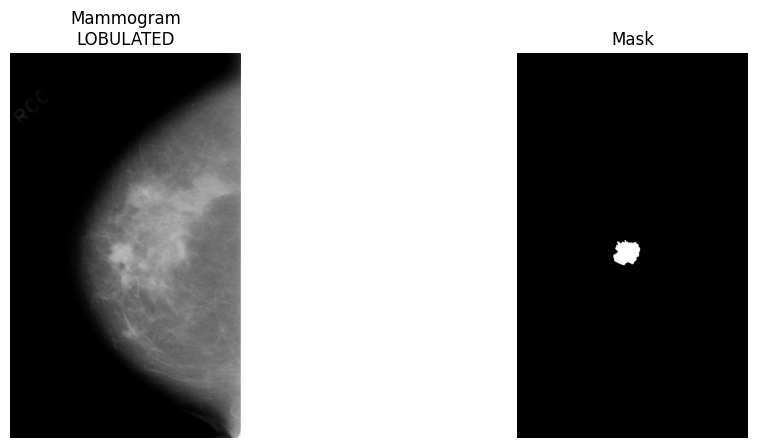

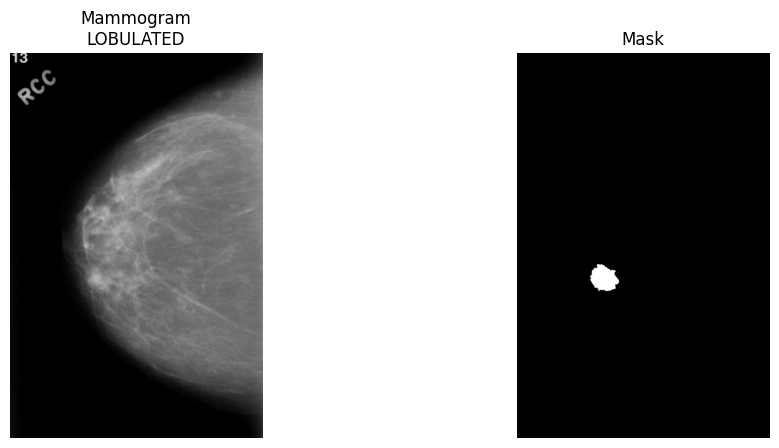

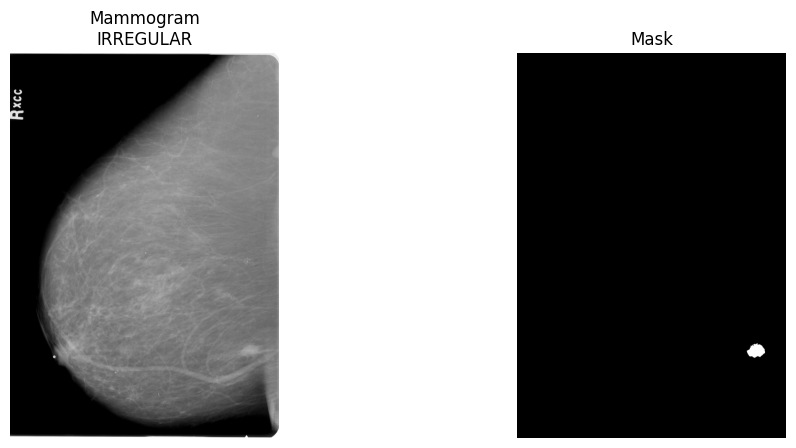

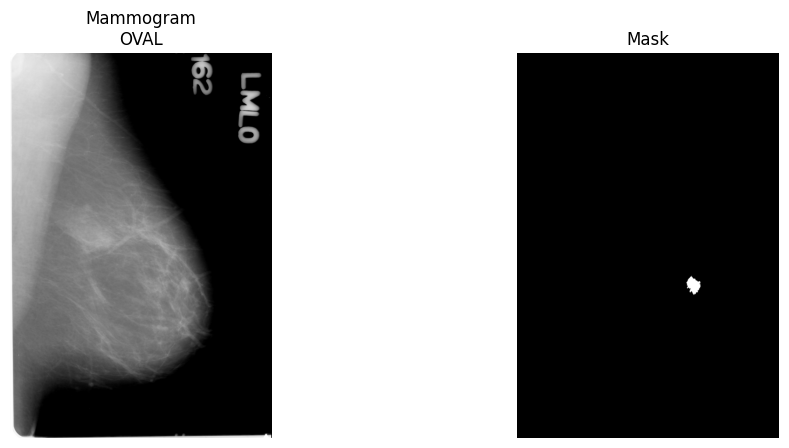

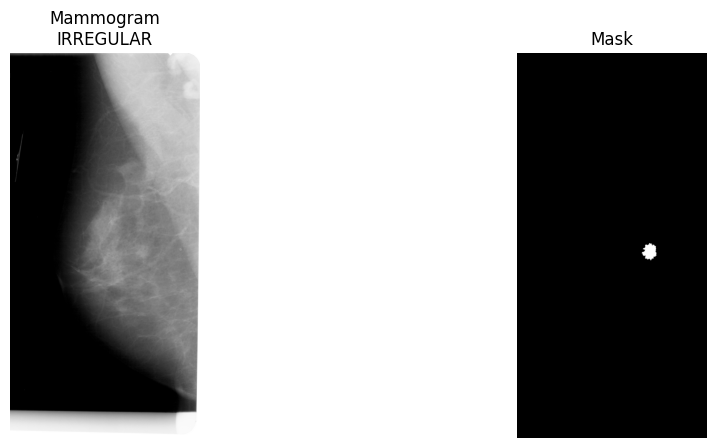

In [29]:
import cv2
import matplotlib.pyplot as plt

for i in range(5):

    img_path, mask_path, shape = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    ax[0].imshow(img, cmap="gray")
    ax[0].set_title(f"Mammogram\n{shape}")
    ax[0].axis("off")

    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Mask")
    ax[1].axis("off")

    plt.show()

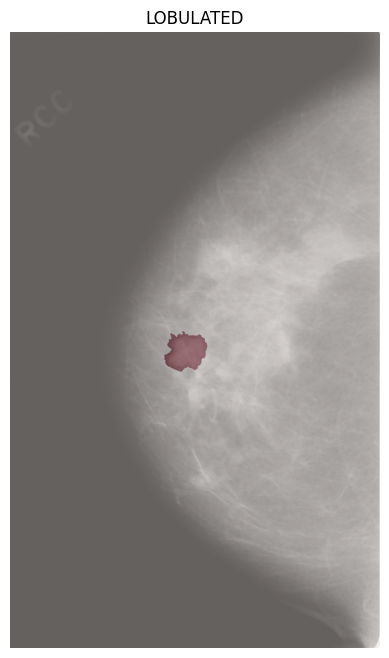

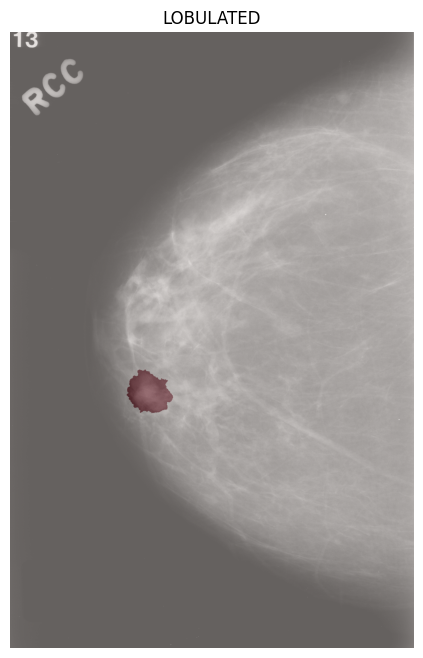

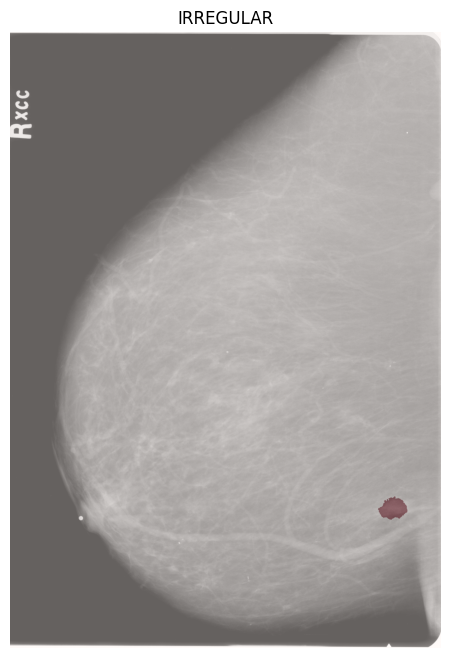

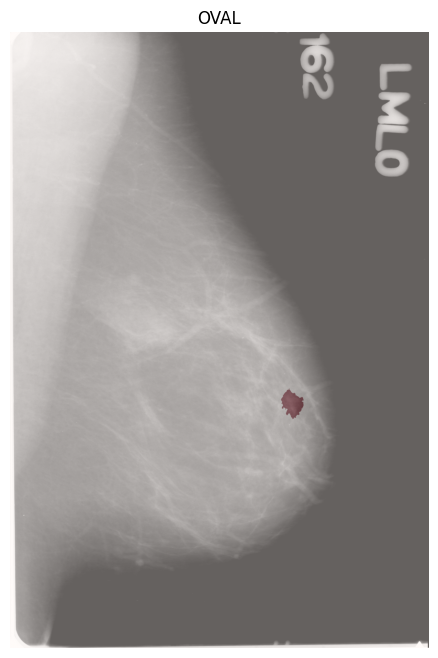

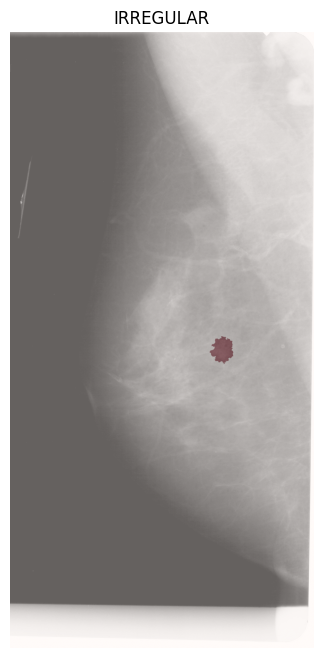

In [30]:
for i in range(5):

    img_path, mask_path, shape = pairs[i]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    mask = cv2.resize(
        mask,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    plt.figure(figsize=(8,8))

    plt.imshow(img, cmap="gray")
    plt.imshow(mask, cmap="Reds", alpha=0.4)

    plt.title(shape)

    plt.axis("off")

    plt.show()

In [31]:
import cv2
import numpy as np

def right_orientation(img):
    """
    Make every mammogram face the same direction.
    If the breast is on the left half, flip horizontally.
    """

    h, w = img.shape

    left_half = img[:, :w//2]
    right_half = img[:, w//2:]

    left_pixels = np.count_nonzero(left_half)
    right_pixels = np.count_nonzero(right_half)

    # Breast on left -> flip
    if left_pixels > right_pixels:
        img = cv2.flip(img, 1)

    return img

In [32]:
import cv2
import numpy as np

def remove_background(img):

    # Create binary image
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return img

    # Largest contour = breast region
    largest = max(contours, key=cv2.contourArea)

    # Create mask
    mask = np.zeros_like(img)
    cv2.drawContours(mask, [largest], -1, 255, thickness=-1)

    # Keep only breast
    breast = cv2.bitwise_and(img, img, mask=mask)

    return breast

In [83]:
def preprocess_image(path, resize=True):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Orientation correction
    img = right_orientation(img)

    # Remove background
    img = remove_background(img)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    img = clahe.apply(img)

    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Resize only if requested
    if resize:
        img = cv2.resize(img, (256, 256))

    img = img.astype(np.float32) / 255.0

    return img

In [33]:
# def preprocess_image(path):

#     img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# # Orientation correction
#     img = right_orientation(img)

# # Remove background
#     img = remove_background(img)

#     clahe = cv2.createCLAHE(
#         clipLimit=2.0,
#         tileGridSize=(8,8)
#     )
#     img = clahe.apply(img)

#     img = cv2.GaussianBlur(img, (3,3), 0)

#     img = cv2.resize(img, (256,256))

#     img = img.astype(np.float32) / 255.0

#     return img


import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image_steps(path):

    original = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Step 1: Orientation Fix
    orientation = right_orientation(original.copy())

    # Step 2: Background Removal
    background = remove_background(orientation.copy())

    # Step 3: CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    clahe_img = clahe.apply(background.copy())

    # Step 4: Gaussian Blur
    blur = cv2.GaussianBlur(clahe_img, (3,3), 0)

    # Step 5: Resize
    resized = cv2.resize(blur, (256,256))

    # Step 6: Normalize
    normalized = resized.astype(np.float32) / 255.0

    return {
        "Original": original,
        "Orientation Fix": orientation,
        "Background Removal": background,
        "CLAHE": clahe_img,
        "Blur": blur,
        "Resize (256×256)": resized,
        "Normalize": normalized
    }

In [34]:
def preprocess_image(path):

    steps = preprocess_image_steps(path)

    return steps["Normalize"]

In [35]:
import os

os.makedirs("preprocessing_steps", exist_ok=True)

# Call preprocess_image_steps to get the dictionary of steps
steps = preprocess_image_steps(pairs[0][0])

for name, img in steps.items():

    filename = name.replace(" ", "_").replace("(","").replace(")","")

    if img.dtype == np.float32:
        img = (img*255).astype(np.uint8)

    cv2.imwrite(f"preprocessing_steps/{filename}.png", img)

In [84]:
def preprocess_mask(path, resize=True):

    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    mask = right_orientation(mask)

    if resize:
        mask = cv2.resize(
            mask,
            (256, 256),
            interpolation=cv2.INTER_NEAREST
        )

    # Binary mask
    mask = (mask > 0).astype(np.uint8)

    return mask

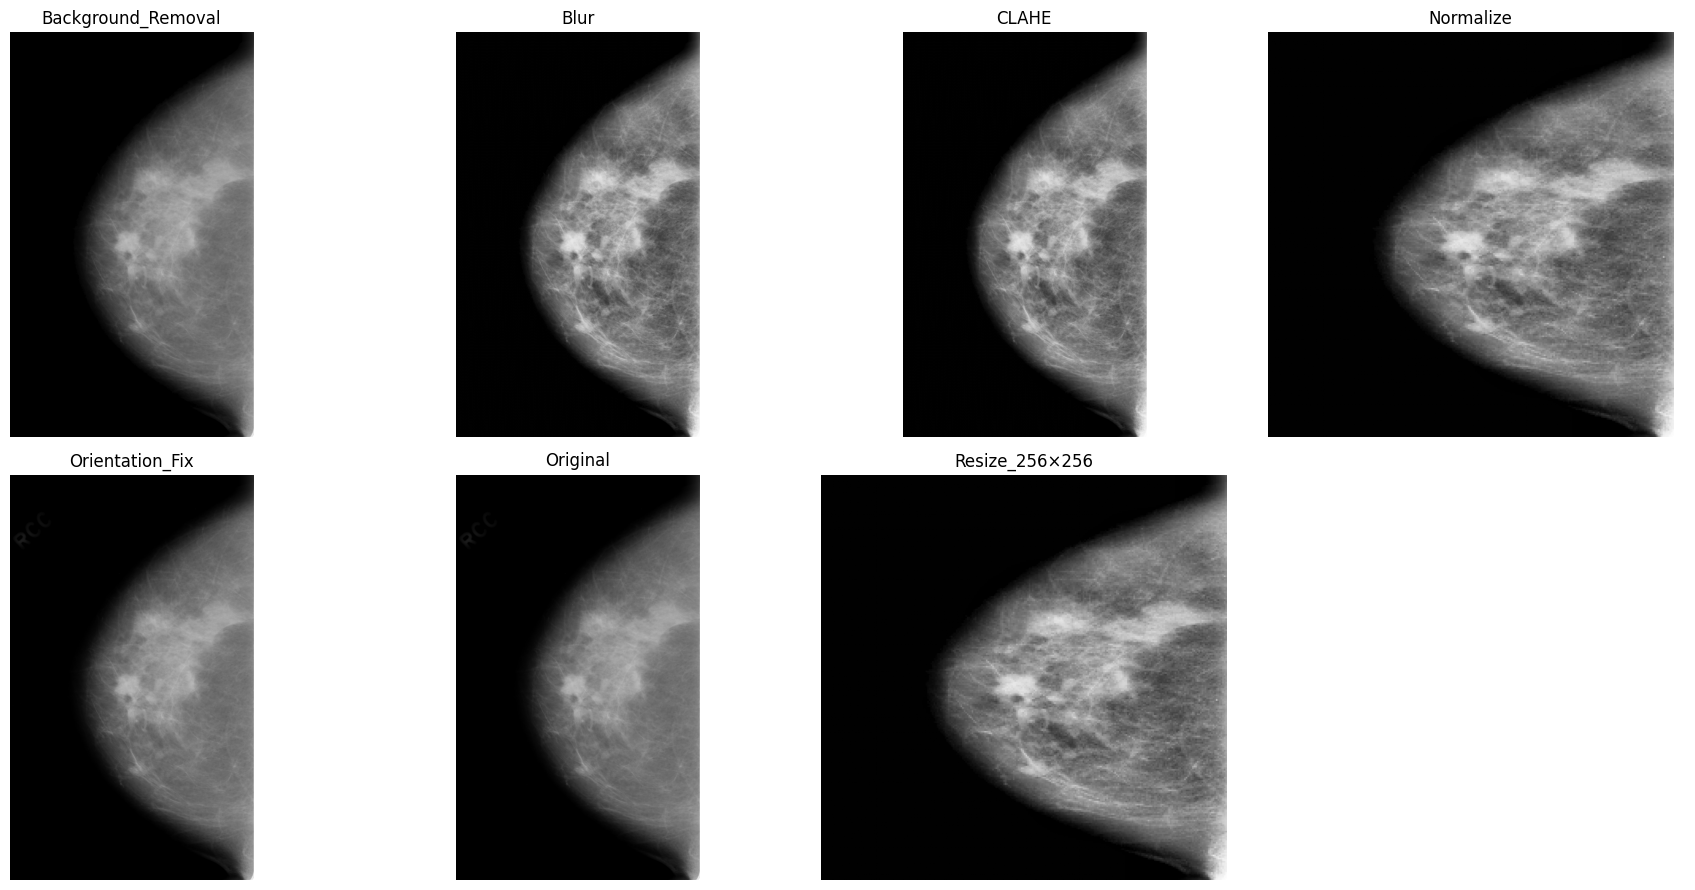

In [37]:
import os
import cv2
import matplotlib.pyplot as plt

folder = "preprocessing_steps"

files = sorted(os.listdir(folder))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, file in zip(axes, files):
    img = cv2.imread(os.path.join(folder, file), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(file.replace(".png",""))
    ax.axis('off')

# Hide unused subplots
for i in range(len(files), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import time

shape_to_label = {
    "AMORPHOUS": 0,
    "PUNCTATE": 1,
    "LUCENT_CENTER": 2
}

X = []
Y = []
shape_labels = []

start = time.time()

for i, (img_path, mask_path, shape) in enumerate(pairs):

    t0 = time.time()

    X.append(preprocess_image(img_path))
    Y.append(preprocess_mask(mask_path))
    shape_labels.append(shape_to_label[shape])

    if (i + 1) % 50 == 0:
        print(f"{i+1}/{len(pairs)} processed "
              f"({time.time()-start:.1f} sec)")


In [40]:
X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.uint8)
shape_labels = np.array(shape_labels, dtype=np.int64)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Shape labels:", shape_labels.shape)

X shape: (1260, 256, 256, 1)
Y shape: (1260, 256, 256, 1)
Shape labels: (1260,)


In [42]:
import os
import cv2

processed_img_dir = os.path.join(OUTPUT_DIR, "processed_images")
processed_mask_dir = os.path.join(OUTPUT_DIR, "processed_masks")

os.makedirs(processed_img_dir, exist_ok=True)
os.makedirs(processed_mask_dir, exist_ok=True)

for i, (img_path, mask_path, shape) in enumerate(pairs):

    img = preprocess_image(img_path)
    mask = preprocess_mask(mask_path)

    cv2.imwrite(
        os.path.join(processed_img_dir, f"img_{i:04d}.png"),
        (img * 255).astype("uint8")
    )

    cv2.imwrite(
        os.path.join(processed_mask_dir, f"mask_{i:04d}.png"),
        (mask * 255).astype("uint8")
    )

In [43]:
import cv2

img = cv2.imread(pairs[0][0], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(pairs[0][1], cv2.IMREAD_GRAYSCALE)

print(img is None)
print(mask is None)

print(img.shape if img is not None else None)
print(mask.shape if mask is not None else None)

False
False
(4600, 2760)
(4600, 2760)


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

boxed_dir = os.path.join(OUTPUT_DIR, "boxed_images")
roi_img_dir = os.path.join(OUTPUT_DIR, "roi_images")
roi_mask_dir = os.path.join(OUTPUT_DIR, "roi_masks")

os.makedirs(boxed_dir, exist_ok=True)
os.makedirs(roi_img_dir, exist_ok=True)
os.makedirs(roi_mask_dir, exist_ok=True)

ROI_X = []
ROI_Y = []
ROI_SHAPES = []
roi_pair_indices = []   # original `pairs` index for each successful ROI entry

for i, (img_path, mask_path, shape) in enumerate(tqdm(pairs)):

    # Get FULL-RESOLUTION versions (resize=False) instead of the
    # already-downsized 256x256 X[i]/Y[i]. This is what preserves
    # detail in the crop.
    img_full = preprocess_image(img_path, resize=False)
    mask_full = preprocess_mask(mask_path, resize=False)

    img = (img_full * 255).astype(np.uint8)
    mask = (mask_full * 255).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        continue

    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    # Adaptive padding (now scaled correctly since w,h are in
    # full-resolution pixels, not 256x256 pixels)
    # NOTE: calcifications are much smaller than masses, so the same
    # padding formula still applies -- it scales with the lesion's own
    # bounding box, not a fixed mass-sized default.
    padding = max(100, int(max(w, h) * 1.5))

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, img.shape[1])
    y2 = min(y + h + padding, img.shape[0])

    # Draw padded box
    boxed = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(boxed, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.imwrite(
        os.path.join(boxed_dir, f"img_{i:04d}.png"),
        boxed
    )

    # Crop ROI at full resolution
    roi_img = img[y1:y2, x1:x2]
    roi_mask = mask[y1:y2, x1:x2]

    crop_h, crop_w = roi_img.shape

    # Choose interpolation based on whether we're shrinking or
    # enlarging the crop -- this is the key fix for the pixelation.
    # AREA is only correct when shrinking; CUBIC is correct when enlarging.
    img_interp = cv2.INTER_AREA if (crop_w >= 128 and crop_h >= 128) else cv2.INTER_CUBIC

    roi_img = cv2.resize(
        roi_img,
        (128, 128),
        interpolation=img_interp
    )

    # Masks are binary -- always use nearest neighbor regardless of
    # up/down scaling, to keep hard edges (no gray "blended" pixels)
    roi_mask = cv2.resize(
        roi_mask,
        (128, 128),
        interpolation=cv2.INTER_NEAREST
    )

    # Save cropped images
    cv2.imwrite(
        os.path.join(roi_img_dir, f"roi_{i:04d}.png"),
        roi_img
    )

    cv2.imwrite(
        os.path.join(roi_mask_dir, f"roi_mask_{i:04d}.png"),
        roi_mask
    )

    # Store arrays
    ROI_X.append(roi_img / 255.0)
    ROI_Y.append(roi_mask // 255)
    ROI_SHAPES.append(shape_labels[i])
    roi_pair_indices.append(i)

# Convert to numpy arrays
ROI_X = np.array(ROI_X, dtype=np.float32)[..., None]
ROI_Y = np.array(ROI_Y, dtype=np.uint8)[..., None]
ROI_SHAPES = np.array(ROI_SHAPES, dtype=np.int64)

# Patient id for each ROI entry, aligned to ROI_X/ROI_Y/ROI_SHAPES --
# needed to reuse the same patient-level train/val/test split as the
# full-image dataset (see the split cells below).
roi_patient_ids = [patient_ids[i] for i in roi_pair_indices]

print("ROI_X:", ROI_X.shape)
print("ROI_Y:", ROI_Y.shape)
print("ROI_SHAPES:", ROI_SHAPES.shape)

# Save arrays -- CALC_ prefix so these never collide with the
# mass-shape NEW_ROI_X.npy / NEW_ROI_Y.npy already in this Drive folder
np.save(os.path.join(OUTPUT_DIR, "CALC_ROI_X.npy"), ROI_X)
np.save(os.path.join(OUTPUT_DIR, "CALC_ROI_Y.npy"), ROI_Y)
np.save(os.path.join(OUTPUT_DIR, "calc_shape_labels.npy"), ROI_SHAPES)


In [ ]:
np.save(os.path.join(OUTPUT_DIR,"calc_X.npy"),X)
np.save(os.path.join(OUTPUT_DIR,"calc_Y.npy"),Y)
np.save(os.path.join(OUTPUT_DIR,"calc_shape_labels.npy"),shape_labels)


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np

patient_ids_arr = np.array(patient_ids)

# Step 1: split all patients into train vs temp (80/20). StratifiedGroupKFold
# keeps every image from a given patient in the SAME split (no leakage),
# while still balancing the shape-label distribution across splits.
sgkf_outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, temp_idx = next(
    sgkf_outer.split(np.zeros(len(shape_labels)), shape_labels, groups=patient_ids_arr)
)

# Step 2: split temp (20%) into val/test (50/50), again grouped + stratified
temp_shape_labels = shape_labels[temp_idx]
temp_patient_ids = patient_ids_arr[temp_idx]

sgkf_inner = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)
val_rel_idx, test_rel_idx = next(
    sgkf_inner.split(np.zeros(len(temp_idx)), temp_shape_labels, groups=temp_patient_ids)
)

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

train_patients = set(patient_ids_arr[train_idx])
val_patients = set(patient_ids_arr[val_idx])
test_patients = set(patient_ids_arr[test_idx])

# Sanity check -- no patient should ever appear in more than one split
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

print(f"Train: {len(train_idx)} images, {len(train_patients)} patients")
print(f"Val:   {len(val_idx)} images, {len(val_patients)} patients")
print(f"Test:  {len(test_idx)} images, {len(test_patients)} patients")

# Save the patient -> split assignment so the ROI split (next cell) can
# reuse the EXACT same patients per split -- keeps the full-image dataset
# and the ROI dataset consistent with each other (no cross-dataset leakage).
patient_split = {}
for p in train_patients:
    patient_split[p] = "train"
for p in val_patients:
    patient_split[p] = "val"
for p in test_patients:
    patient_split[p] = "test"

X_train, Y_train, S_train = X[train_idx], Y[train_idx], shape_labels[train_idx]
X_val,   Y_val,   S_val   = X[val_idx],   Y[val_idx],   shape_labels[val_idx]
X_test,  Y_test,  S_test  = X[test_idx],  Y[test_idx],  shape_labels[test_idx]

# calc_ prefix -- avoids overwriting the mass-shape X_train.npy etc.
# already saved in this Drive folder.
np.save(os.path.join(OUTPUT_DIR,"calc_X_train.npy"),X_train)
np.save(os.path.join(OUTPUT_DIR,"calc_Y_train.npy"),Y_train)
np.save(os.path.join(OUTPUT_DIR,"calc_shape_train.npy"),S_train)

np.save(os.path.join(OUTPUT_DIR,"calc_X_val.npy"),X_val)
np.save(os.path.join(OUTPUT_DIR,"calc_Y_val.npy"),Y_val)
np.save(os.path.join(OUTPUT_DIR,"calc_shape_val.npy"),S_val)

np.save(os.path.join(OUTPUT_DIR,"calc_X_test.npy"),X_test)
np.save(os.path.join(OUTPUT_DIR,"calc_Y_test.npy"),Y_test)
np.save(os.path.join(OUTPUT_DIR,"calc_shape_test.npy"),S_test)


In [ ]:
import numpy as np

roi_patient_ids_arr = np.array(roi_patient_ids)

# Reuse the patient -> split mapping from the full-image split above,
# instead of an independent random split. This guarantees the same
# patients land in train/val/test for BOTH datasets -- no patient
# shows up in, say, the full-image train set and the ROI test set.
roi_train_idx = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "train"])
roi_val_idx   = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "val"])
roi_test_idx  = np.array([i for i, p in enumerate(roi_patient_ids_arr) if patient_split.get(p) == "test"])

ROI_X_train, ROI_Y_train, ROI_S_train = ROI_X[roi_train_idx], ROI_Y[roi_train_idx], ROI_SHAPES[roi_train_idx]
ROI_X_val,   ROI_Y_val,   ROI_S_val   = ROI_X[roi_val_idx],   ROI_Y[roi_val_idx],   ROI_SHAPES[roi_val_idx]
ROI_X_test,  ROI_Y_test,  ROI_S_test  = ROI_X[roi_test_idx],  ROI_Y[roi_test_idx],  ROI_SHAPES[roi_test_idx]

print(f"ROI Train: {len(roi_train_idx)} images")
print(f"ROI Val:   {len(roi_val_idx)} images")
print(f"ROI Test:  {len(roi_test_idx)} images")

# CALC_ prefix -- keeps these files separate from the mass-shape
# NEW_ROI_X_train.npy etc. already saved in this Drive folder.
np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_X_train.npy"),ROI_X_train)
np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_Y_train.npy"),ROI_Y_train)
np.save(os.path.join(OUTPUT_DIR,"calc_roi_shape_train.npy"),ROI_S_train)

np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_X_val.npy"),ROI_X_val)
np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_Y_val.npy"),ROI_Y_val)
np.save(os.path.join(OUTPUT_DIR,"calc_roi_shape_val.npy"),ROI_S_val)

np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_X_test.npy"),ROI_X_test)
np.save(os.path.join(OUTPUT_DIR,"CALC_ROI_Y_test.npy"),ROI_Y_test)
np.save(os.path.join(OUTPUT_DIR,"calc_roi_shape_test.npy"),ROI_S_test)


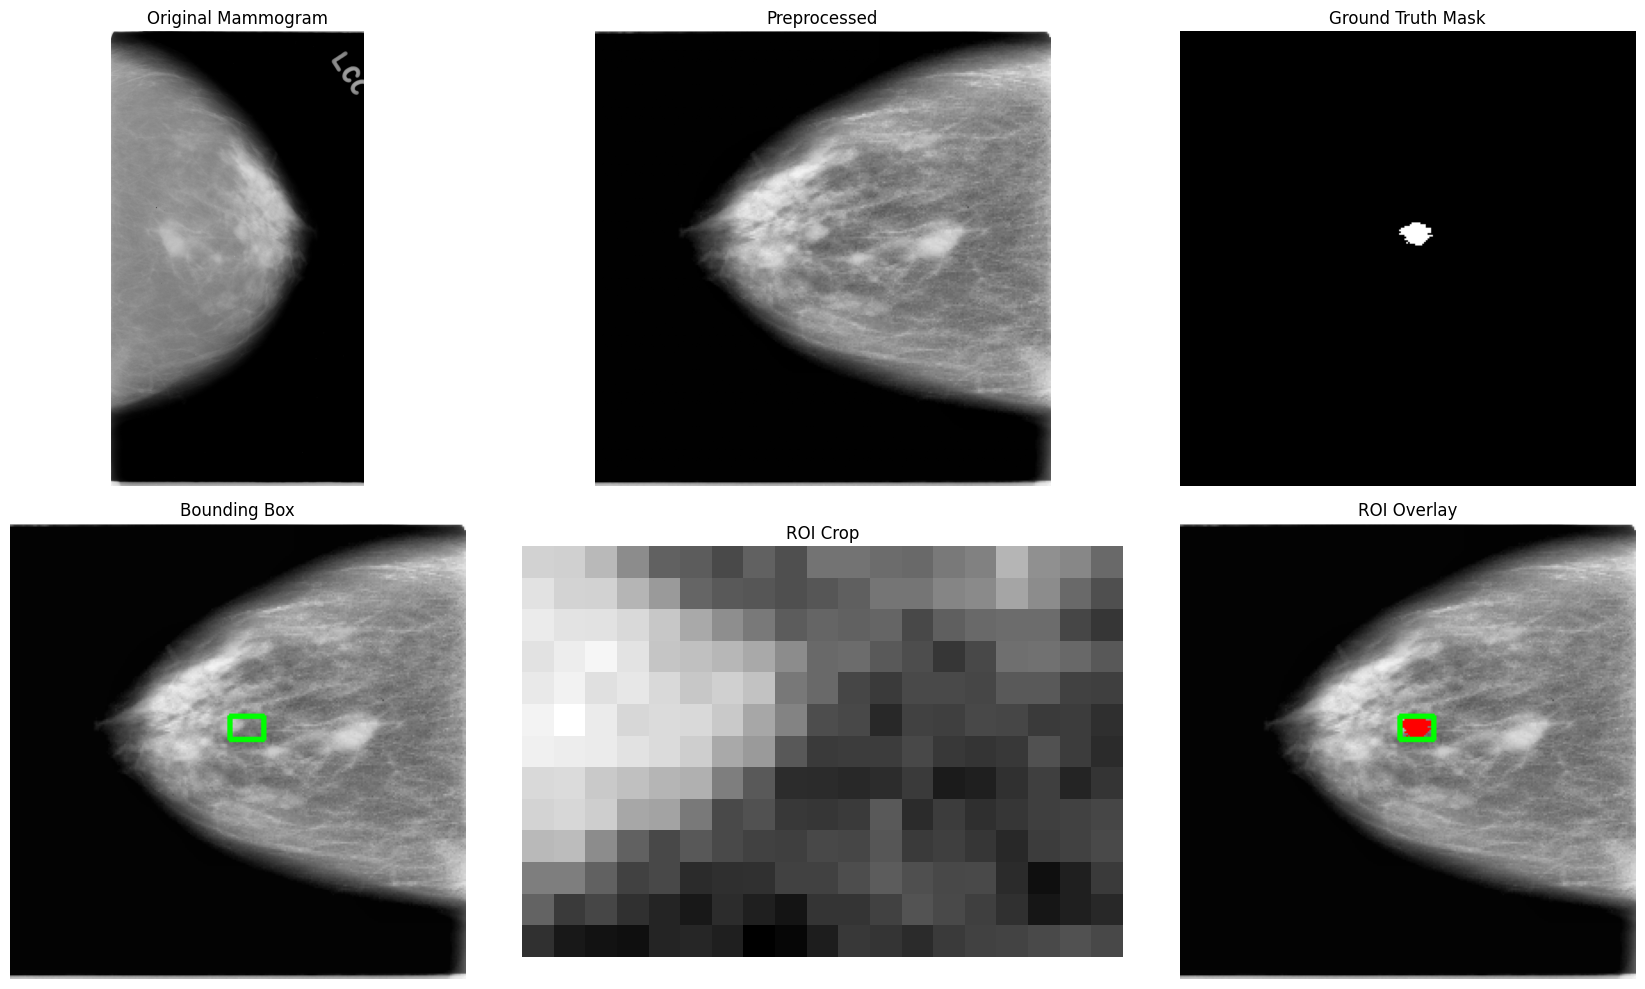

Random Sample Index: 490


In [82]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Select a random image
idx = random.randint(0, len(pairs)-1)

img_path, mask_path, shape = pairs[idx]
# Original mammogram
original = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Preprocessed image and mask
preprocessed = (X[idx].squeeze()*255).astype(np.uint8)
mask = (Y[idx].squeeze()*255).astype(np.uint8)

# Find bounding box
contours, _ = cv2.findContours(mask,
                               cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

boxed = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

if len(contours) > 0:

    cnt = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(cnt)

    # Draw bounding box
    cv2.rectangle(boxed, (x,y), (x+w,y+h), (0,255,0), 2)

    # ROI
    roi = preprocessed[y:y+h, x:x+w]

    # Overlay
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)
    overlay[mask>0] = [255,0,0]      # lesion in blue
    cv2.rectangle(overlay,(x,y),(x+w,y+h),(0,255,0),2)

else:
    roi = np.zeros((50,50),dtype=np.uint8)
    overlay = cv2.cvtColor(preprocessed, cv2.COLOR_GRAY2BGR)

# Plot
fig, ax = plt.subplots(2,3,figsize=(18,10))

ax[0,0].imshow(original,cmap='gray')
ax[0,0].set_title("Original Mammogram")
ax[0,0].axis("off")

ax[0,1].imshow(preprocessed,cmap='gray')
ax[0,1].set_title("Preprocessed")
ax[0,1].axis("off")

ax[0,2].imshow(mask,cmap='gray')
ax[0,2].set_title("Ground Truth Mask")
ax[0,2].axis("off")

ax[1,0].imshow(boxed)
ax[1,0].set_title("Bounding Box")
ax[1,0].axis("off")

ax[1,1].imshow(roi,cmap='gray')
ax[1,1].set_title("ROI Crop")
ax[1,1].axis("off")

ax[1,2].imshow(overlay)
ax[1,2].set_title("ROI Overlay")
ax[1,2].axis("off")

plt.tight_layout()
plt.show()

print("Random Sample Index:", idx)